# Using the SWOTGEM toolbox 
This notebook is to help use the SWOTGEM toolbox. Note that the GEM field is built for the Southern Ocean, with the northern extreme roughly the subtropical front. 
Don't hestitate to get in touch if you need some help (jimbokwyatt@gmail.com) :) 


## This requires the field GEM_smoothed_2000dbar_for_SWOT.nc - available on Zenodo at https://zenodo.org/uploads/18889113 under the file name GEM_smoothed_2000dbar_for_SWOT.nc

In [18]:
%pip install -e "./SWOTGEM_toolbox_v0.1.0/SWOTGEM_toolbox[plot]"

Obtaining file:///D:/SWOTGEM/toolbox/SWOTGEM_toolbox_v0.1.0/SWOTGEM_toolbox
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for swotgem-toolbox (pyproject.toml): started
  Building editable for swotgem-toolbox (pyproject.toml): finished with status 'done'
  Created wheel for swotgem-toolbox: filename=swotgem_toolbox-0.1.0-0.editable-py3-none-any.whl size=1515 sha256=3526906fb00ed80e8ecc3390bc404cfcba21e08083593317a400205e283bf520
  Stored in directory: C:\Users\jamesw\AppData\Local\Temp\pip-ephem-wheel-cache-kn3ug838\wheels\cd

In [19]:
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr
from swotgem import (
    crop_swot_dataset,
    iter_reconstructed_swaths,
    reconstruct_swath,
    swath_xy_gradients,
)
from swotgem.plotting import plot_gradient_fields, plot_swath_fields
import numpy as np
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from swotgem import (
    iter_reconstructed_swaths,
    select_gem_pressure,
)


## File Paths, boundaries

These values describe this particular analysis, so they stay in the notebook rather than inside toolbox functions.

In [20]:
# Change paths accordingly 

gem_file = Path("GEM_smoothed_2000dbar_for_SWOT.nc")
swot_file = Path(r"J:\BACKUP\FRODING\jamesw\SWOT_IFR\EXPERT_DATA\cycle_048\SWOT_L3_LR_SSH_Expert_048_091_20260331T020245_20260331T025411_v3.0.nc")
cycle_directory = Path(r"J:\BACKUP\FRODING\jamesw\SWOT_IFR\EXPERT_DATA\cycle_048")

pressure_index = 50 #the GEM is in pressure intervals of 10 dbar. 50 = 500 dbar
latitude_bounds = (-70.0, -45.0)

## Reconstruct one swath

In [14]:
with xr.open_dataset(gem_file) as gem, xr.open_dataset(swot_file) as raw:
    swath = crop_swot_dataset(raw, lat_bounds=latitude_bounds)
    if swath is None:
        raise ValueError("Pass is outside the selected region")

    fields = reconstruct_swath(
        gem,
        swath,
        pressure_index=pressure_index,
    ).load()
    pressure = float(gem.pressure.isel(pressure=pressure_index))

fields

<xarray.Dataset> Size: 5MB
Dimensions:    (num_lines: 1559, num_pixels: 69)
Coordinates:
    pressure   int64 8B 500
    longitude  (num_lines, num_pixels) float64 861kB -118.8 -118.7 ... -93.32
    latitude   (num_lines, num_pixels) float64 861kB -69.99 -70.0 ... -45.01
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    CT         (num_lines, num_pixels) float64 861kB nan nan nan ... nan nan nan
    SA         (num_lines, num_pixels) float64 861kB nan nan nan ... nan nan nan
    sigma0     (num_lines, num_pixels) float64 861kB nan nan nan ... nan nan nan
    ssh        (num_lines, num_pixels) float64 861kB nan nan nan ... nan nan nan

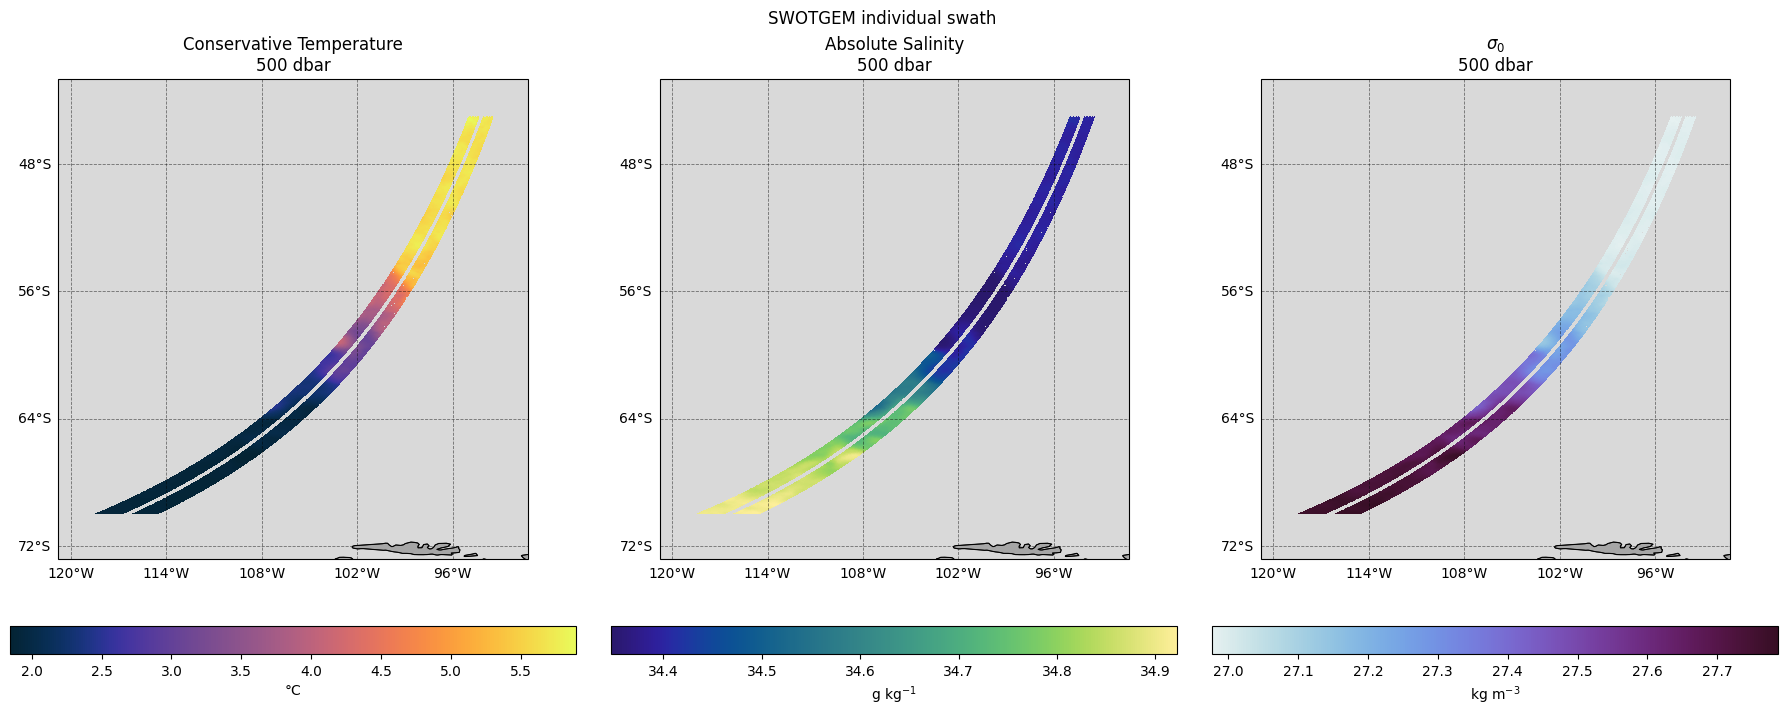

In [15]:
fig, axes = plot_swath_fields(fields, pressure=pressure)
fig.suptitle("SWOTGEM individual swath")
plt.show()

## Dataset at all pressure levels

In [26]:
with (
    xr.open_dataset(gem_file) as gem,
    xr.open_dataset(swot_file) as raw,
):

    swath = crop_swot_dataset(
        raw,
        lat_bounds=latitude_bounds,
    )

    if swath is None:
        raise ValueError(
            "Pass is outside the selected region"
        )

    satGEM_on_swath = reconstruct_swath(
        gem,
        swath,
        pressure = None
    ).load()

satGEM_on_swath

<xarray.Dataset> Size: 519MB
Dimensions:    (pressure: 200, num_lines: 1559, num_pixels: 69)
Coordinates:
  * pressure   (pressure) int64 2kB 0 10 20 30 40 ... 1950 1960 1970 1980 1990
    longitude  (num_lines, num_pixels) float64 861kB -118.8 -118.7 ... -93.32
    latitude   (num_lines, num_pixels) float64 861kB -69.99 -70.0 ... -45.01
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    CT         (num_lines, num_pixels, pressure) float64 172MB nan nan ... nan
    SA         (num_lines, num_pixels, pressure) float64 172MB nan nan ... nan
    sigma0     (num_lines, num_pixels, pressure) float64 172MB nan nan ... nan
    ssh        (num_lines, num_pixels) float64 861kB nan nan nan ... nan nan nan

## Metric-aware density gradients

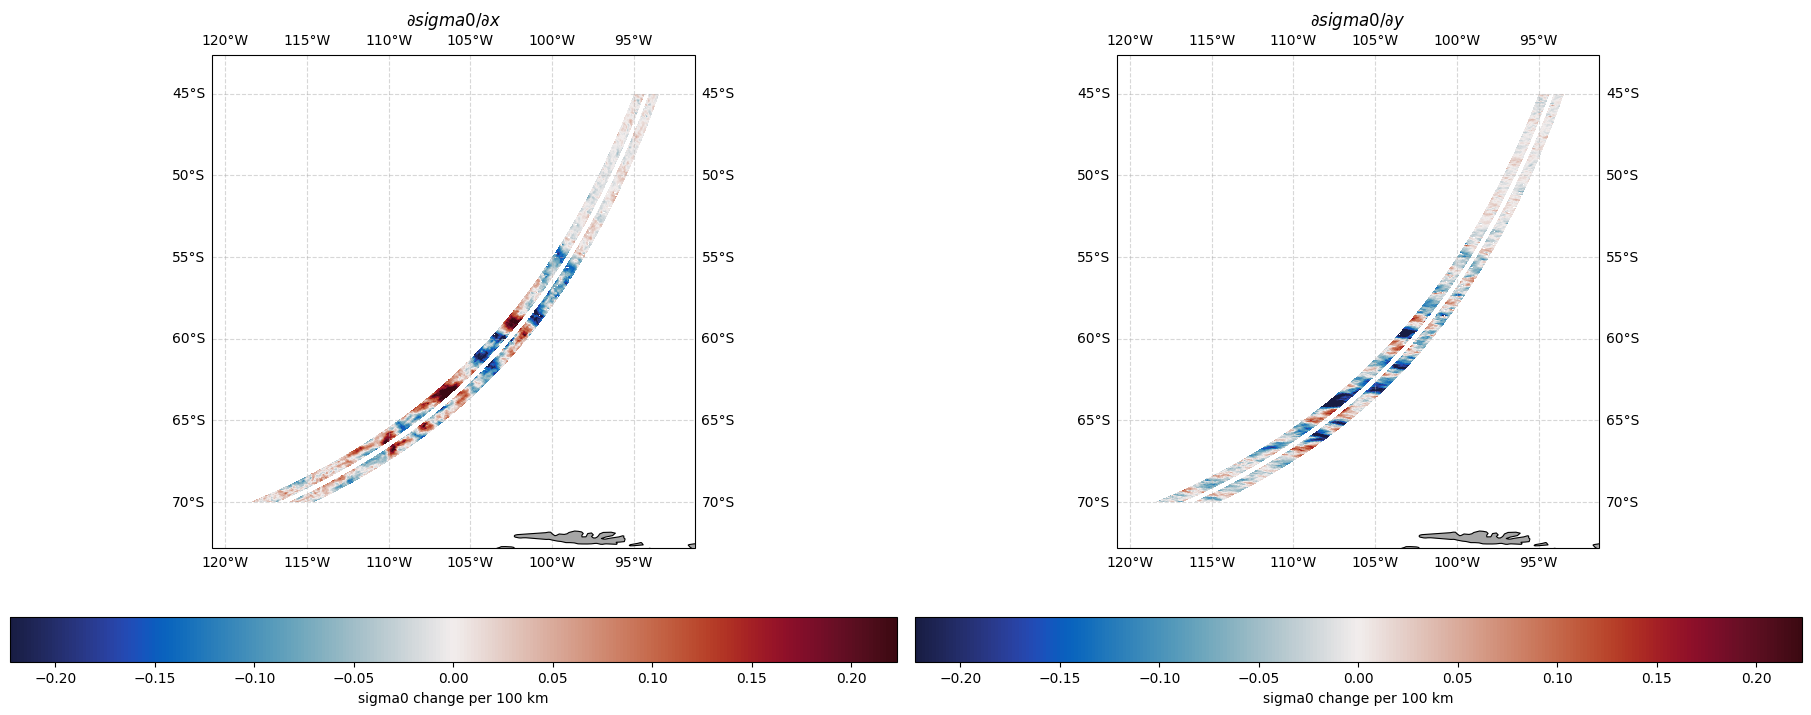

In [6]:
gradients = swath_xy_gradients(
    fields["sigma0"],
    fields["longitude"],
    fields["latitude"],
)

dsigma_dx_100km = gradients["dsigma0_dx"] * 100_000
dsigma_dy_100km = gradients["dsigma0_dy"] * 100_000
gradient_magnitude_100km = gradients["sigma0_gradient_magnitude"] * 100_000

fig, axes = plot_gradient_fields(
    gradients,
    fields["longitude"],
    fields["latitude"],
    variable_name="sigma0",
)
plt.show()

## Process a full cycle

The iterator loads each reconstructed pass before its source NetCDF file closes. Plot, analyse, or save each `fields_now` dataset inside the loop.

In [ ]:
swot_files = sorted(cycle_directory.glob("*.nc"))

with xr.open_dataset(gem_file) as gem:
    for path, fields_now in iter_reconstructed_swaths(
        swot_files,
        gem,
        lat_bounds=latitude_bounds,
        pressure_index=pressure_index,
    ):
        print(path.name, fields_now.sizes)

## Plot a full cycle

1: SWOT_L3_LR_SSH_Expert_048_001_20260327T205231_20260327T214357_v3.0.nc
2: SWOT_L3_LR_SSH_Expert_048_002_20260327T214358_20260327T223524_v3.0.nc
3: SWOT_L3_LR_SSH_Expert_048_003_20260327T223524_20260327T232651_v3.0.nc
4: SWOT_L3_LR_SSH_Expert_048_004_20260327T232651_20260328T001818_v3.0.nc
5: SWOT_L3_LR_SSH_Expert_048_005_20260328T001818_20260328T010944_v3.0.nc
6: SWOT_L3_LR_SSH_Expert_048_006_20260328T010945_20260328T020111_v3.0.nc
7: SWOT_L3_LR_SSH_Expert_048_007_20260328T020112_20260328T025238_v3.0.nc
8: SWOT_L3_LR_SSH_Expert_048_008_20260328T025239_20260328T034405_v3.0.nc
9: SWOT_L3_LR_SSH_Expert_048_009_20260328T034405_20260328T043532_v3.0.nc
10: SWOT_L3_LR_SSH_Expert_048_010_20260328T043532_20260328T052659_v3.0.nc
11: SWOT_L3_LR_SSH_Expert_048_011_20260328T052659_20260328T061826_v3.0.nc
12: SWOT_L3_LR_SSH_Expert_048_012_20260328T061826_20260328T070952_v3.0.nc
13: SWOT_L3_LR_SSH_Expert_048_013_20260328T070953_20260328T080119_v3.0.nc
14: SWOT_L3_LR_SSH_Expert_048_014_20260328T0801

C:\Users\jamesw\anaconda3\envs\hav\Lib\site-packages\xarray\core\missing.py:588: RuntimeWarning: All-NaN slice encountered
  minval = np.nanmin(new_x_loaded)
C:\Users\jamesw\anaconda3\envs\hav\Lib\site-packages\xarray\core\missing.py:589: RuntimeWarning: All-NaN slice encountered
  maxval = np.nanmax(new_x_loaded)


92: SWOT_L3_LR_SSH_Expert_048_092_20260331T025412_20260331T034538_v3.0.nc
93: SWOT_L3_LR_SSH_Expert_048_094_20260331T043705_20260331T052831_v3.0.nc
94: SWOT_L3_LR_SSH_Expert_048_095_20260331T052832_20260331T061959_v3.0.nc
95: SWOT_L3_LR_SSH_Expert_048_096_20260331T061959_20260331T071126_v3.0.nc
96: SWOT_L3_LR_SSH_Expert_048_098_20260331T080253_20260331T085419_v3.0.nc
97: SWOT_L3_LR_SSH_Expert_048_099_20260331T085419_20260331T094546_v3.0.nc
98: SWOT_L3_LR_SSH_Expert_048_100_20260331T094546_20260331T103712_v3.0.nc
99: SWOT_L3_LR_SSH_Expert_048_101_20260331T103713_20260331T112839_v3.0.nc
100: SWOT_L3_LR_SSH_Expert_048_102_20260331T112840_20260331T122006_v3.0.nc
101: SWOT_L3_LR_SSH_Expert_048_103_20260331T122006_20260331T131133_v3.0.nc
102: SWOT_L3_LR_SSH_Expert_048_104_20260331T131133_20260331T140259_v3.0.nc
103: SWOT_L3_LR_SSH_Expert_048_105_20260331T140300_20260331T145426_v3.0.nc
104: SWOT_L3_LR_SSH_Expert_048_106_20260331T145427_20260331T154553_v3.0.nc
105: SWOT_L3_LR_SSH_Expert_048_10

C:\Users\jamesw\anaconda3\envs\hav\Lib\site-packages\xarray\core\missing.py:588: RuntimeWarning: All-NaN slice encountered
  minval = np.nanmin(new_x_loaded)
C:\Users\jamesw\anaconda3\envs\hav\Lib\site-packages\xarray\core\missing.py:589: RuntimeWarning: All-NaN slice encountered
  maxval = np.nanmax(new_x_loaded)


168: SWOT_L3_LR_SSH_Expert_048_170_20260402T214703_20260402T223829_v3.0.nc


...

302: SWOT_L3_LR_SSH_Expert_048_304_20260407T164058_20260407T173224_v3.0.nc
303: SWOT_L3_LR_SSH_Expert_048_305_20260407T173225_20260407T182352_v3.0.nc
304: SWOT_L3_LR_SSH_Expert_048_306_20260407T182352_20260407T191518_v3.0.nc
305: SWOT_L3_LR_SSH_Expert_048_307_20260407T191519_20260407T200645_v3.0.nc
306: SWOT_L3_LR_SSH_Expert_048_308_20260407T200645_20260407T205812_v3.0.nc
307: SWOT_L3_LR_SSH_Expert_048_309_20260407T205812_20260407T214939_v3.0.nc
308: SWOT_L3_LR_SSH_Expert_048_310_20260407T214939_20260407T224105_v3.0.nc


C:\Users\jamesw\anaconda3\envs\hav\Lib\site-packages\xarray\core\missing.py:588: RuntimeWarning: All-NaN slice encountered
  minval = np.nanmin(new_x_loaded)
C:\Users\jamesw\anaconda3\envs\hav\Lib\site-packages\xarray\core\missing.py:589: RuntimeWarning: All-NaN slice encountered
  maxval = np.nanmax(new_x_loaded)


309: SWOT_L3_LR_SSH_Expert_048_311_20260407T224106_20260407T233232_v3.0.nc
310: SWOT_L3_LR_SSH_Expert_048_312_20260407T233233_20260408T002359_v3.0.nc
311: SWOT_L3_LR_SSH_Expert_048_313_20260408T002359_20260408T011526_v3.0.nc
312: SWOT_L3_LR_SSH_Expert_048_314_20260408T011526_20260408T020653_v3.0.nc
313: SWOT_L3_LR_SSH_Expert_048_315_20260408T020653_20260408T025820_v3.0.nc
314: SWOT_L3_LR_SSH_Expert_048_316_20260408T025820_20260408T034946_v3.0.nc
315: SWOT_L3_LR_SSH_Expert_048_317_20260408T034947_20260408T044113_v3.0.nc
316: SWOT_L3_LR_SSH_Expert_048_318_20260408T044114_20260408T053240_v3.0.nc
317: SWOT_L3_LR_SSH_Expert_048_319_20260408T053241_20260408T062408_v3.0.nc
318: SWOT_L3_LR_SSH_Expert_048_320_20260408T062408_20260408T071534_v3.0.nc
319: SWOT_L3_LR_SSH_Expert_048_321_20260408T071534_20260408T080701_v3.0.nc
320: SWOT_L3_LR_SSH_Expert_048_322_20260408T080701_20260408T085827_v3.0.nc
321: SWOT_L3_LR_SSH_Expert_048_323_20260408T085828_20260408T094954_v3.0.nc
322: SWOT_L3_LR_SSH_Exper

C:\Users\jamesw\anaconda3\envs\hav\Lib\site-packages\xarray\core\missing.py:588: RuntimeWarning: All-NaN slice encountered
  minval = np.nanmin(new_x_loaded)
C:\Users\jamesw\anaconda3\envs\hav\Lib\site-packages\xarray\core\missing.py:589: RuntimeWarning: All-NaN slice encountered
  maxval = np.nanmax(new_x_loaded)


360: SWOT_L3_LR_SSH_Expert_048_362_20260409T182454_20260409T191620_v3.0.nc
361: SWOT_L3_LR_SSH_Expert_048_363_20260409T191621_20260409T200747_v3.0.nc
362: SWOT_L3_LR_SSH_Expert_048_364_20260409T200748_20260409T205914_v3.0.nc
363: SWOT_L3_LR_SSH_Expert_048_365_20260409T205915_20260409T215041_v3.0.nc
364: SWOT_L3_LR_SSH_Expert_048_366_20260409T215041_20260409T224208_v3.0.nc
365: SWOT_L3_LR_SSH_Expert_048_367_20260409T224208_20260409T233335_v3.0.nc
366: SWOT_L3_LR_SSH_Expert_048_368_20260409T233335_20260410T002502_v3.0.nc
367: SWOT_L3_LR_SSH_Expert_048_369_20260410T002502_20260410T011628_v3.0.nc
368: SWOT_L3_LR_SSH_Expert_048_370_20260410T011629_20260410T020755_v3.0.nc
369: SWOT_L3_LR_SSH_Expert_048_371_20260410T020756_20260410T025922_v3.0.nc
370: SWOT_L3_LR_SSH_Expert_048_372_20260410T025923_20260410T035049_v3.0.nc
371: SWOT_L3_LR_SSH_Expert_048_373_20260410T035049_20260410T044216_v3.0.nc
372: SWOT_L3_LR_SSH_Expert_048_374_20260410T044216_20260410T053342_v3.0.nc
373: SWOT_L3_LR_SSH_Exper

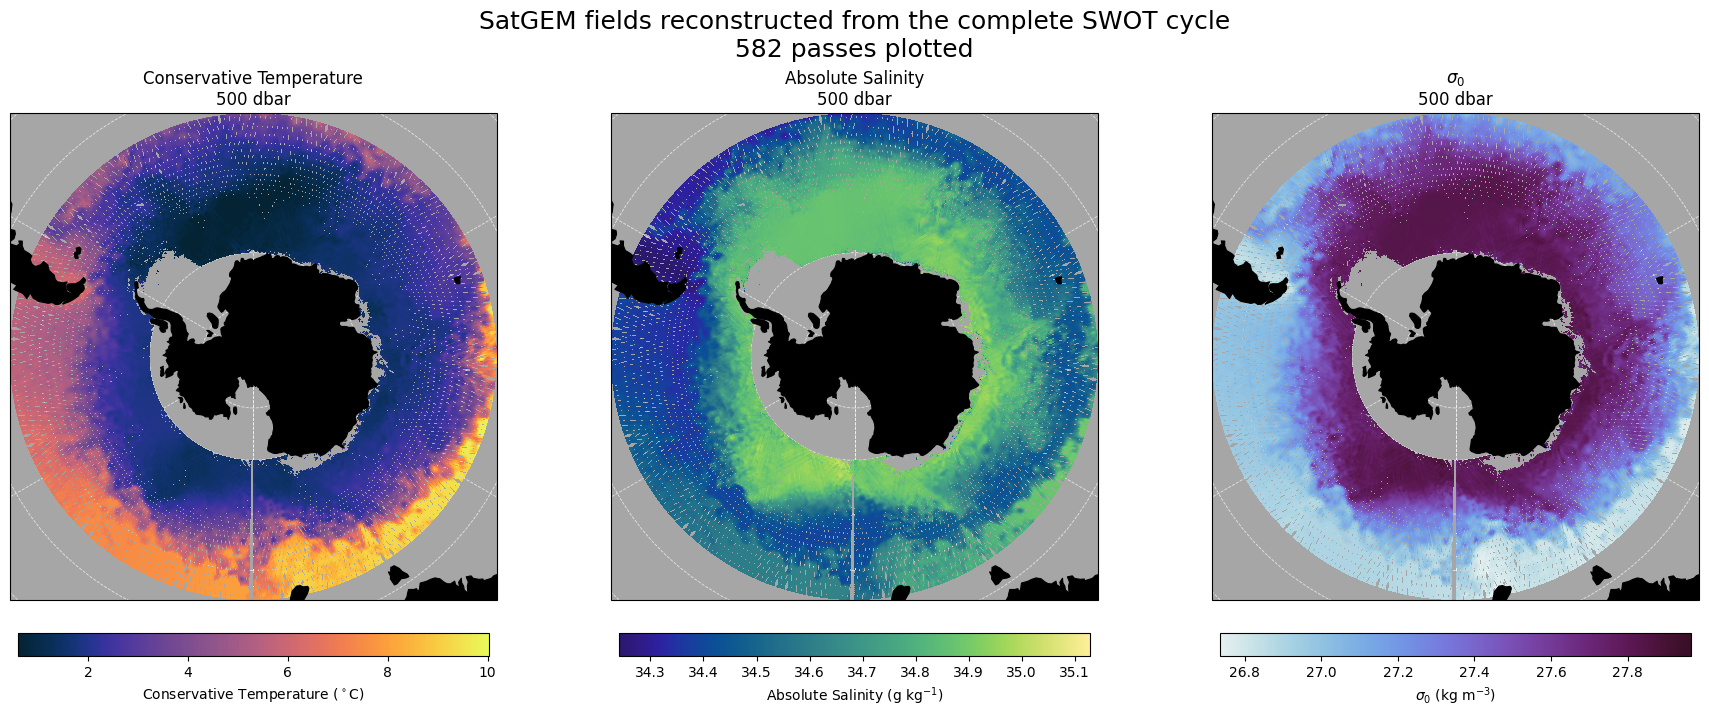

In [9]:
swot_files = sorted(cycle_directory.glob("*.nc"))


data_crs = ccrs.PlateCarree()
map_projection = ccrs.SouthPolarStereo()


with xr.open_dataset(gem_file) as gem:

    # ========================================================
    # Select GEM pressure and establish common colour limits
    # ========================================================

    gem_at_pressure = select_gem_pressure(
        gem,
        pressure_index=pressure_index,
    )

    pressure_value = float(
        gem["pressure"].isel(pressure=pressure_index)
    )

    sigma0_lookup = xr.apply_ufunc(
        gsw.sigma0,
        gem_at_pressure["sal"],
        gem_at_pressure["temp"],
        dask="parallelized",
        output_dtypes=[float],
    )

    norms = [
        Normalize(
            vmin=float(gem_at_pressure["temp"].min(skipna=True).compute()),
            vmax=float(gem_at_pressure["temp"].max(skipna=True).compute()),
        ),
        Normalize(
            vmin=float(gem_at_pressure["sal"].min(skipna=True).compute()),
            vmax=float(gem_at_pressure["sal"].max(skipna=True).compute()),
        ),
        Normalize(
            vmin=float(sigma0_lookup.min(skipna=True).compute()),
            vmax=float(sigma0_lookup.max(skipna=True).compute()),
        ),
    ]

    cmaps = [
        cmocean.cm.thermal,
        cmocean.cm.haline,
        cmocean.cm.dense,
    ]

    titles = [
        "Conservative Temperature",
        "Absolute Salinity",
        r"$\sigma_0$",
    ]

    colourbar_labels = [
        r"Conservative Temperature ($^\circ$C)",
        r"Absolute Salinity (g kg$^{-1}$)",
        r"$\sigma_0$ (kg m$^{-3}$)",
    ]

    # ========================================================
    # Create one set of axes for the entire cycle
    # ========================================================

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(18, 7),
        subplot_kw={"projection": map_projection},
        constrained_layout=True,
    )

    for ax, title in zip(axes, titles):

        ax.set_extent(
            [-180, 180, -80, -45],
            crs=data_crs,
        )

        ax.set_facecolor("0.65")

        ax.add_feature(
            cfeature.LAND,
            facecolor="black",
            zorder=10,
        )

        ax.coastlines(
            color="black",
            linewidth=0.8,
            zorder=11,
        )

        ax.gridlines(
            crs=data_crs,
            linestyle="--",
            color="white",
            linewidth=0.6,
            alpha=0.7,
        )

        ax.set_title(
            f"{title}\n{pressure_value:.0f} dbar"
        )

    # ========================================================
    # Add every reconstructed swath to the same axes
    # ========================================================

    number_plotted = 0

    swath_iterator = iter_reconstructed_swaths(
        swot_files,
        gem,
        lat_bounds=latitude_bounds,
        pressure_index=pressure_index,
    )

    for path, fields_now in swath_iterator:

        longitude = fields_now["longitude"]
        latitude = fields_now["latitude"]

        fields = [
            fields_now["CT"],
            fields_now["SA"],
            fields_now["sigma0"],
        ]

        for ax, field, cmap, norm in zip(
            axes,
            fields,
            cmaps,
            norms,
        ):

            ax.pcolormesh(
                longitude,
                latitude,
                field,
                transform=data_crs,
                shading="auto",
                cmap=cmap,
                norm=norm,
                rasterized=True,
                zorder=2,
            )

        number_plotted += 1
        print(f"{number_plotted}: {path.name}")


# ============================================================
# Add one colourbar to each panel
# ============================================================

for ax, cmap, norm, label in zip(
    axes,
    cmaps,
    norms,
    colourbar_labels,
):

    mappable = ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    mappable.set_array([])

    colourbar = fig.colorbar(
        mappable,
        ax=ax,
        orientation="horizontal",
        pad=0.05,
        shrink=0.8,
    )

    colourbar.set_label(label)


fig.suptitle(
    f"SatGEM fields reconstructed from the complete SWOT cycle\n"
    f"{number_plotted} passes plotted",
    fontsize=18,
)

plt.show()

## Download a cycle - you will need your own AVISO account for this

In [ ]:
from getpass import getpass
from pathlib import Path

from swotgem import download_cycle

cycle = 48
username = input("AVISO username: ")
password = getpass("AVISO password: ")
output_directory = Path("EXPERT_DATA") / f"cycle_{cycle:03d}"

files = download_cycle(
    cycle,
    output_directory,
    username=username,
    password=password,
)
print(f"Ready: {len(files)} NetCDF files in {output_directory}")
